# Website Traffic Analysis

## Introduction

Website traffic analysis helps organizations understand how visitors interact with their digital platforms. By analyzing traffic patterns, geographic information, content engagement and link activity, businesses can identify high-performing areas and make data-driven decisions to improve user engagement and conversions.

This project analyzes website traffic data to identify important patterns in visitor activity across countries, cities, events, artists, albums, tracks and links. The analysis also examines daily and monthly traffic trends to identify periods of high website activity.

The findings are used to provide actionable recommendations for Alfido Tech to improve content strategy, target high-performing markets, optimize website links and strengthen future website tracking.



In [72]:
from google.colab import files
uploaded=files.upload()

Saving traffic.csv to traffic (1).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("traffic.csv")

In [6]:

df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [7]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [8]:
df.dtypes

,0
event,object
date,object
country,object
city,object
artist,object
album,object
track,object
isrc,object
linkid,object


In [9]:
df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [10]:
df.isnull().sum().sum()

np.int64(7190)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [12]:
df.describe()

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [13]:
df.duplicated().sum()

np.int64(103711)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
country,5
city,5
artist,28
album,4
track,4
isrc,6306


In [39]:
df['country'] = df['country'].fillna('Unknown')
df['artist'] = df['artist'].fillna('Unknown')
df['album'] = df['album'].fillna('Unknown')
df['track'] = df['track'].fillna('Unknown')
df['isrc'] = df['isrc'].fillna('Unknown')

In [40]:
city_counts = (
    df[df['city'].notna() &
       (df['city'].str.lower() != 'unknown')]
    ['city']
    .value_counts()
    .head(10)
)

print(city_counts)

city
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Pune            799
Name: count, dtype: int64


In [19]:
df.isnull().sum()

,0
event,0
date,0
country,0
city,0
artist,0
album,0
track,0
isrc,0
linkid,0


In [20]:
df['event'].value_counts()

,count
event,
pageview,73360
click,32499
preview,16708


In [23]:
# Display all column names clearly
print("Traffic Dataset Columns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

print("\nDataset Shape:", df.shape)

Traffic Dataset Columns:
0 : event
1 : date
2 : country
3 : city
4 : artist
5 : album
6 : track
7 : isrc
8 : linkid

Dataset Shape: (122567, 9)


In [25]:
df.shape

(122567, 9)

In [26]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [27]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

Start Date: 2021-08-19 00:00:00
End Date: 2021-08-25 00:00:00


In [28]:
daily_traffic = df.groupby(df['date'].dt.date).size()

print(daily_traffic.head())

date
2021-08-19    21156
2021-08-20    18536
2021-08-21    16701
2021-08-22    16927
2021-08-23    16415
dtype: int64


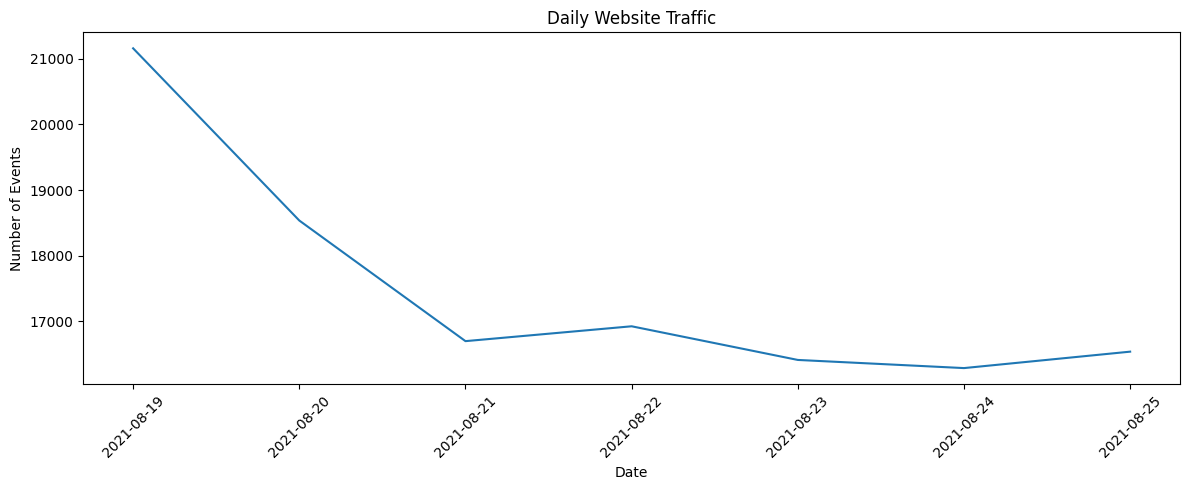

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(daily_traffic.index, daily_traffic.values)

plt.title("Daily Website Traffic")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
busiest_day = daily_traffic.idxmax()
highest_traffic = daily_traffic.max()

print("Busiest Day:", busiest_day)
print("Number of Events:", highest_traffic)

Busiest Day: 2021-08-19
Number of Events: 21156


In [31]:
country_counts = df['country'].value_counts().head(10)

print(country_counts)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64


In [33]:
import seaborn as sns

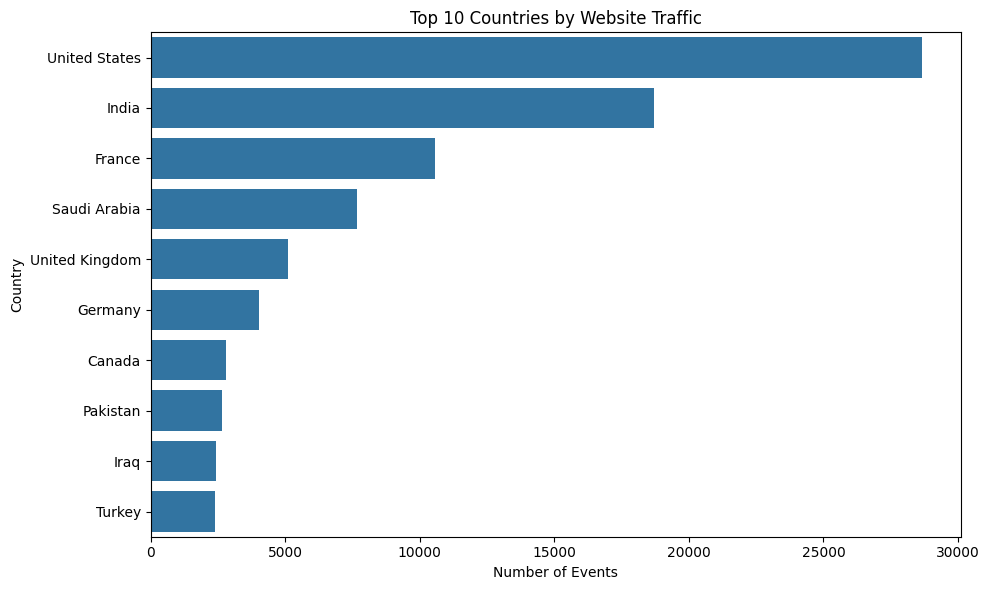

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [35]:
top_country = country_counts.idxmax()
top_country_traffic = country_counts.max()

print("Top Country:", top_country)
print("Number of Events:", top_country_traffic)

Top Country: United States
Number of Events: 28664


In [36]:
city_counts = df['city'].value_counts().head(10)

print(city_counts)

city
Unknown        8802
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64


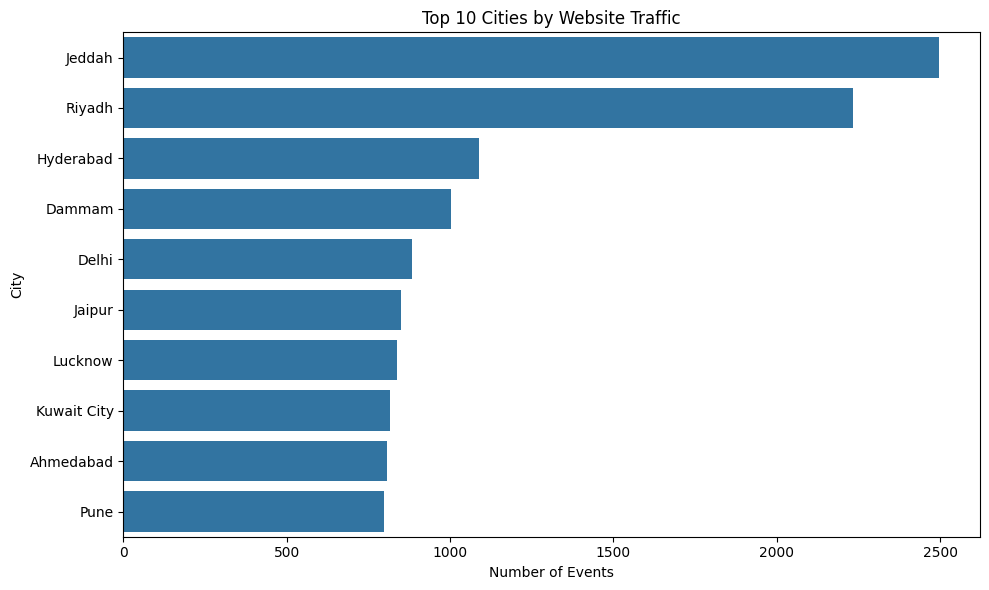

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top 10 Cities by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [41]:
top_city = city_counts.idxmax()
top_city_traffic = city_counts.max()

print("Top City:", top_city)
print("Number of Events:", top_city_traffic)

Top City: Jeddah
Number of Events: 2497


In [44]:
artist_counts = df['artist'].value_counts().head(10)

print(artist_counts)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


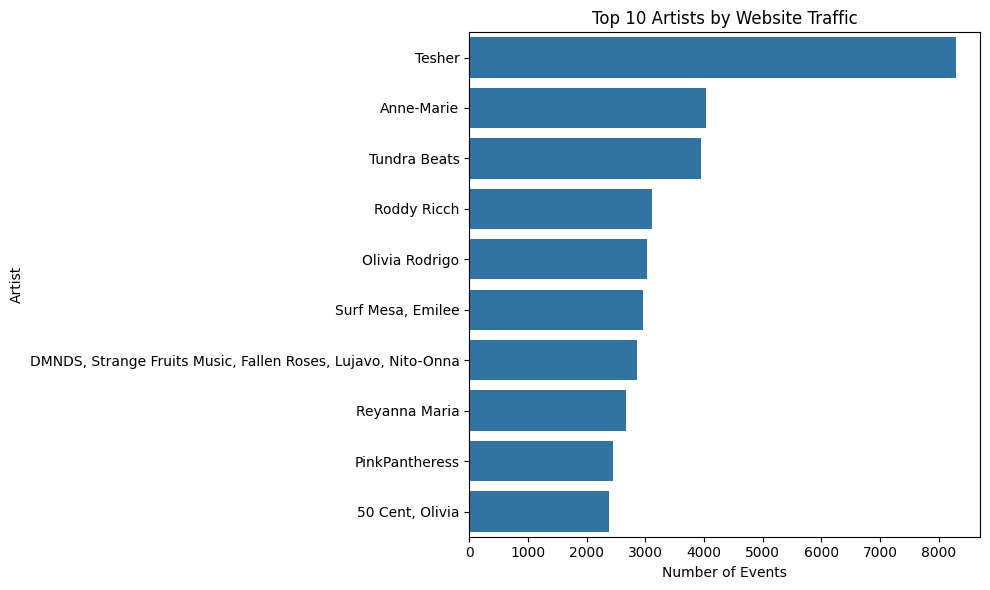

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=artist_counts.values,
    y=artist_counts.index
)

plt.title("Top 10 Artists by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Artist")

plt.tight_layout()
plt.show()

In [46]:
top_artist = artist_counts.idxmax()
top_artist_traffic = artist_counts.max()

print("Top Artist:", top_artist)
print("Number of Events:", top_artist_traffic)

Top Artist: Tesher
Number of Events: 8288


In [47]:
track_counts = df['track'].value_counts().head(10)

print(track_counts)

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


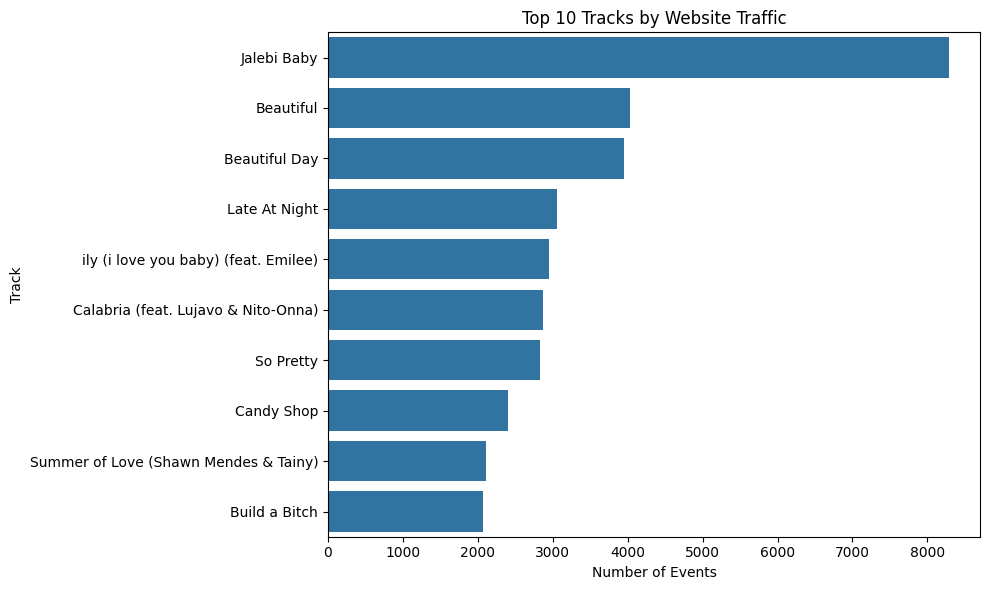

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=track_counts.values,
    y=track_counts.index
)

plt.title("Top 10 Tracks by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Track")

plt.tight_layout()
plt.show()

In [49]:
top_track = track_counts.idxmax()
top_track_traffic = track_counts.max()

print("Top Track:", top_track)
print("Number of Events:", top_track_traffic)

Top Track: Jalebi Baby
Number of Events: 8288


In [50]:
album_counts = df['album'].value_counts().head(10)

print(album_counts)

album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2956
SOUR                                    2878
The Massacre                            2870
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2830
Summer Of Love                          2108
Name: count, dtype: int64


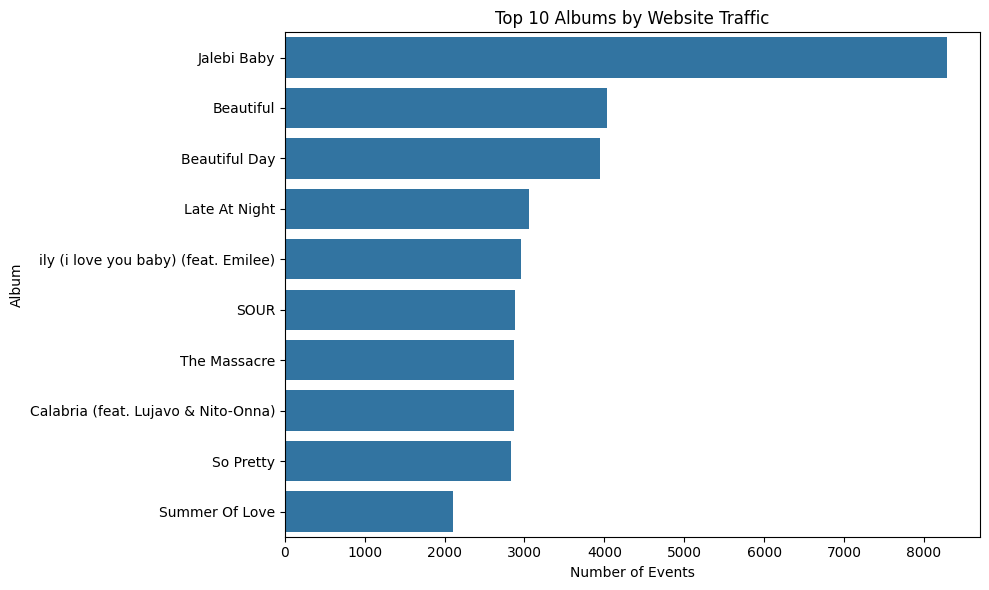

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=album_counts.values,
    y=album_counts.index
)

plt.title("Top 10 Albums by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Album")

plt.tight_layout()
plt.show()

In [52]:
top_album = album_counts.idxmax()
top_album_traffic = album_counts.max()

print("Top Album:", top_album)
print("Number of Events:", top_album_traffic)

Top Album: Jalebi Baby
Number of Events: 8288


In [53]:
link_counts = df['linkid'].value_counts().head(10)

print(link_counts)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2675
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64


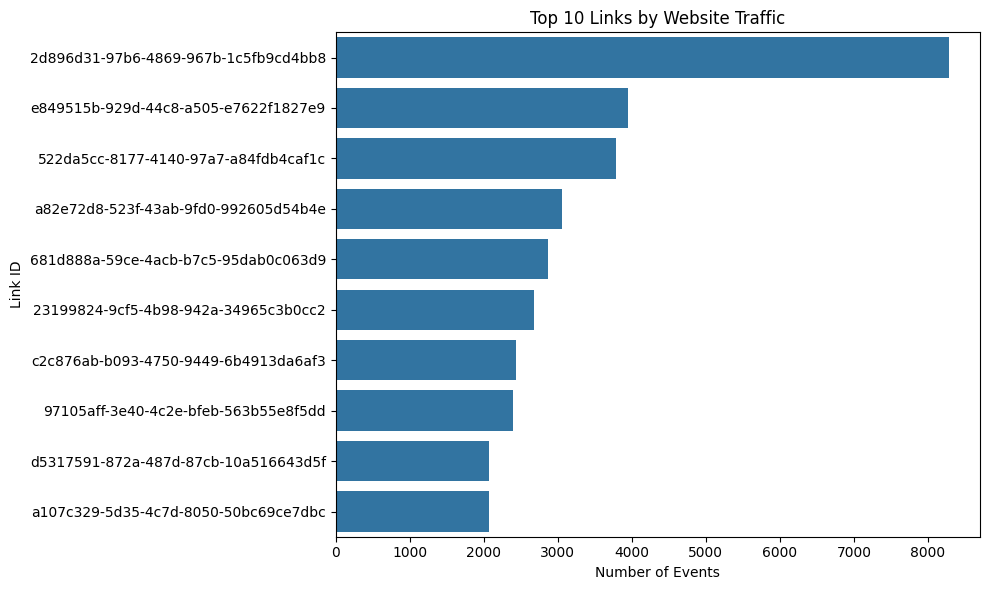

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=link_counts.values,
    y=link_counts.index.astype(str)
)

plt.title("Top 10 Links by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Link ID")

plt.tight_layout()
plt.show()

In [55]:
top_link = link_counts.idxmax()
top_link_traffic = link_counts.max()

print("Top Link ID:", top_link)
print("Number of Events:", top_link_traffic)

Top Link ID: 2d896d31-97b6-4869-967b-1c5fb9cd4bb8
Number of Events: 8288


In [56]:
event_country = pd.crosstab(
    df['country'],
    df['event']
)

display(event_country.head(10))

event,click,pageview,preview
country,,,
Afghanistan,0,2,0
Albania,58,231,58
Algeria,96,328,91
American Samoa,1,3,0
Andorra,0,2,1
Angola,21,40,9
Anguilla,1,4,0
Antigua and Barbuda,1,4,0
Argentina,14,55,14


In [57]:
top_countries = df['country'].value_counts().head(10).index

event_country_top = event_country.loc[
    event_country.index.isin(top_countries)
]

display(event_country_top)

event,click,pageview,preview
country,,,
Canada,840,1702,242
France,2792,6181,1592
Germany,1030,2585,402
India,5360,10565,2764
Iraq,567,1285,592
Pakistan,754,1382,497
Saudi Arabia,1976,3712,1994
Turkey,466,1598,335
United Kingdom,1307,3218,570


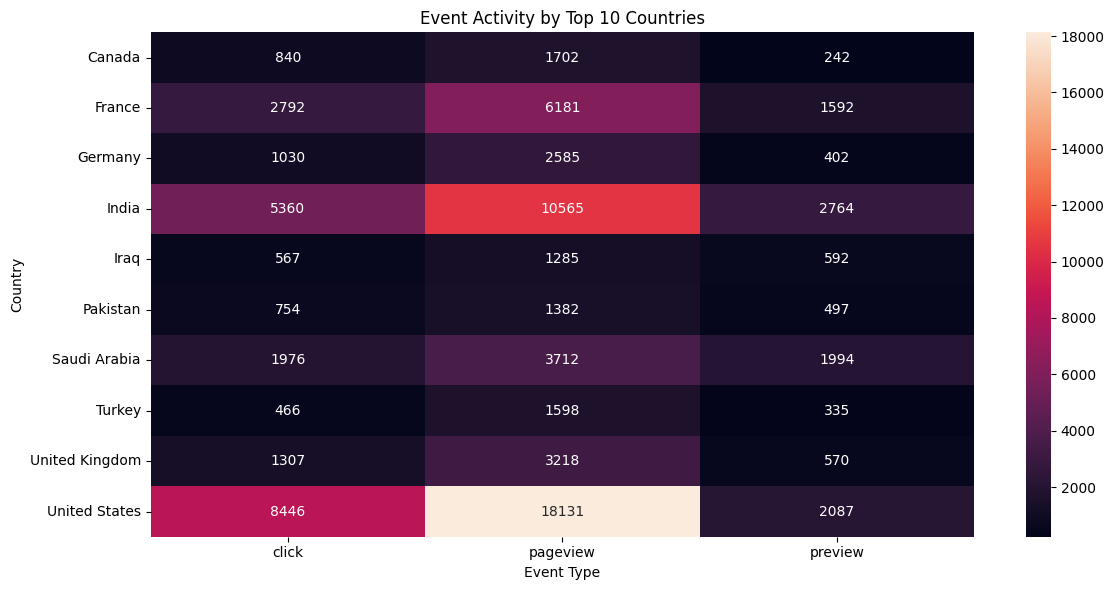

In [58]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    event_country_top,
    annot=True,
    fmt='d'
)

plt.title("Event Activity by Top 10 Countries")
plt.xlabel("Event Type")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [60]:
df['day_of_week'] = df['date'].dt.day_name()

In [61]:
df[['date', 'day_of_week']].head()

,date,day_of_week
0,2021-08-21,Saturday
2,2021-08-21,Saturday
3,2021-08-21,Saturday
4,2021-08-21,Saturday
5,2021-08-21,Saturday


In [62]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_counts = (
    df['day_of_week']
    .value_counts()
    .reindex(day_order)
)

print(day_counts)

day_of_week
Monday       16415
Tuesday      16291
Wednesday    16541
Thursday     21156
Friday       18536
Saturday     16701
Sunday       16927
Name: count, dtype: int64


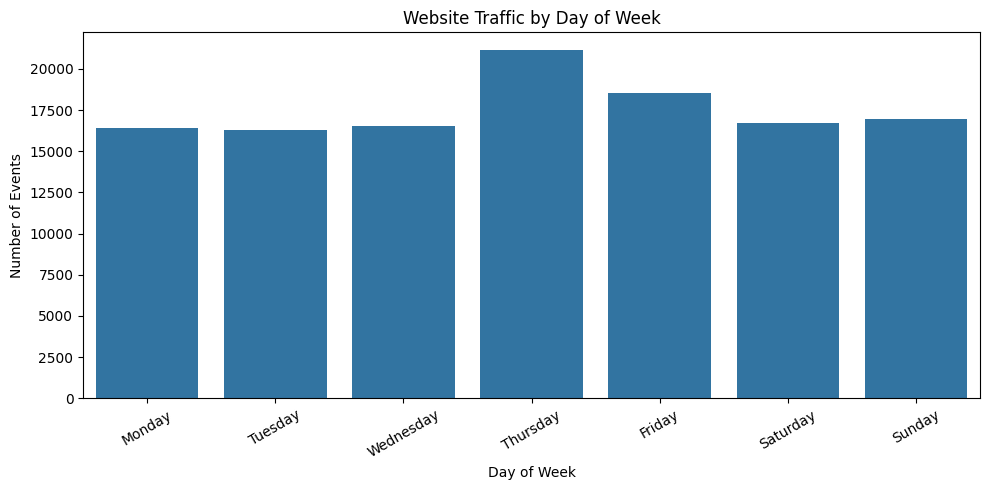

In [63]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_counts.index,
    y=day_counts.values
)

plt.title("Website Traffic by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Events")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [64]:
busiest_day = day_counts.idxmax()
busiest_day_events = day_counts.max()

print("Busiest Day:", busiest_day)
print("Number of Events:", busiest_day_events)

Busiest Day: Thursday
Number of Events: 21156


In [65]:
df['month'] = df['date'].dt.month_name()

print(df[['date', 'month']].head())

        date   month
0 2021-08-21  August
2 2021-08-21  August
3 2021-08-21  August
4 2021-08-21  August
5 2021-08-21  August


In [66]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

month_counts = (
    df['month']
    .value_counts()
    .reindex(month_order)
    .dropna()
)

print(month_counts)

month
August    122567.0
Name: count, dtype: float64


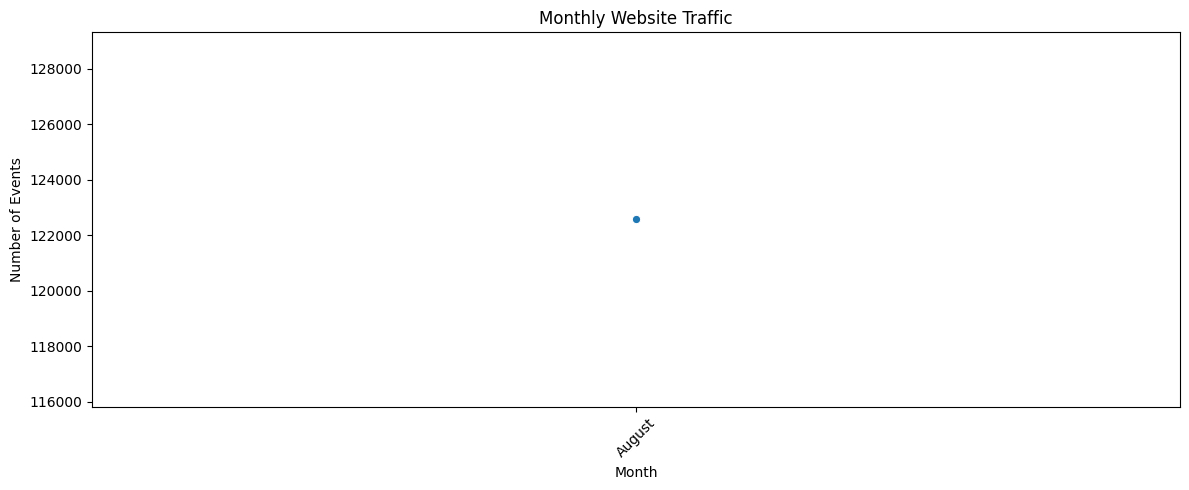

In [67]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=month_counts.index,
    y=month_counts.values,
    marker='o'
)

plt.title("Monthly Website Traffic")
plt.xlabel("Month")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
peak_month = month_counts.idxmax()
peak_month_events = month_counts.max()

print("Peak Traffic Month:", peak_month)
print("Number of Events:", peak_month_events)

Peak Traffic Month: August
Number of Events: 122567.0


In [69]:
total_events = len(df)
unique_countries = df['country'].nunique()
unique_cities = df[df['city'].str.lower() != 'unknown']['city'].nunique()
unique_artists = df['artist'].nunique()
unique_albums = df['album'].nunique()
unique_tracks = df['track'].nunique()
unique_links = df['linkid'].nunique()

print("Total Events:", total_events)
print("Unique Countries:", unique_countries)
print("Unique Known Cities:", unique_cities)
print("Unique Artists:", unique_artists)
print("Unique Albums:", unique_albums)
print("Unique Tracks:", unique_tracks)
print("Unique Links:", unique_links)

Total Events: 122567
Unique Countries: 212
Unique Known Cities: 11992
Unique Artists: 2420
Unique Albums: 3255
Unique Tracks: 3563
Unique Links: 3839


In [70]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Events',
        'Unique Countries',
        'Unique Known Cities',
        'Unique Artists',
        'Unique Albums',
        'Unique Tracks',
        'Unique Links'
    ],
    'Value': [
        total_events,
        unique_countries,
        unique_cities,
        unique_artists,
        unique_albums,
        unique_tracks,
        unique_links
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Events,122567
1,Unique Countries,212
2,Unique Known Cities,11992
3,Unique Artists,2420
4,Unique Albums,3255
5,Unique Tracks,3563
6,Unique Links,3839


**# Business Insights**

- The analysis identified the countries and cities generating the highest website activity, helping identify important geographic markets.
- The most popular artists, albums and tracks received the highest number of events and represent the strongest-performing content.
- The most frequently accessed link IDs indicate which links are associated with greater website activity.
- Daily traffic analysis identified the busiest day of the week, which can help in planning content releases and marketing campaigns.
- Monthly traffic analysis identified the peak traffic month and provides an indication of when website activity was highest.
- Event distribution shows the types of interactions recorded most frequently in the traffic data.

**## Recommendations for Alfido Tech**

### 1. Promote High-Performing Content
Focus promotional activities on the artists, albums and tracks generating the highest traffic to increase audience engagement.

### 2. Target High-Traffic Locations
Use country and city-level traffic patterns to prioritize marketing campaigns in locations with strong website activity.

### 3. Optimize High-Traffic Links
Investigate the most frequently accessed links and ensure that their associated content is relevant, easy to navigate and optimized for user engagement.

### 4. Use Peak Traffic Periods
Schedule important content releases and digital campaigns around the days and months showing higher traffic activity.

### 5. Improve Website Tracking
Implement user IDs, session IDs, timestamps, landing pages, exit pages and referral-source tracking. This will allow Alfido Tech to accurately measure sessions, bounce rate, session duration and conversion journeys in future analyses.

## Data Limitations

The dataset provides event-level information including date, country, city, artist, album, track, ISRC and link ID.

However, it does not contain explicit user IDs, session IDs, timestamps, landing-page URLs, exit-page URLs or referral-source information.

Therefore, metrics such as total users, sessions, bounce rate, average session duration, landing pages, exit pages and referral-source performance cannot be calculated reliably from this dataset.

These limitations should be considered when interpreting the results.

## Conclusion

The website traffic analysis provided insights into visitor activity across geography, content, links and time. The analysis identified high-performing countries, cities, artists, albums, tracks and links, while also highlighting daily and monthly traffic patterns.

These findings can help Alfido Tech focus marketing efforts on high-performing locations and content, optimize frequently accessed links and schedule campaigns during periods of higher traffic.

Although the current dataset provides useful event-level insights, additional tracking information such as user IDs, session IDs, timestamps and referral sources would be required for detailed user-journey, bounce-rate and conversion analysis.